# Gráficas

In [1]:
import requests
import pandas as pd
import time
import os
from dotenv import load_dotenv

# Configuración
load_dotenv()
STEAM_API_KEY = os.getenv("STEAM_API_KEY")

print("1. Obteniendo el Top de juegos actuales...")
url_top = f"https://api.steampowered.com/ISteamChartsService/GetGamesByConcurrentPlayers/v1/?key={STEAM_API_KEY}"
res_top = requests.get(url_top).json()
top_juegos = res_top.get('response', {}).get('ranks', [])[:50] # Top 50 para no tardar demasiado

df_jugadores = pd.DataFrame(top_juegos)
df_jugadores.rename(columns={'concurrent_in_game': 'jugadores_actuales'}, inplace=True)

datos_tienda = []
print("2. Extrayendo metadatos de la tienda (Esto tomará ~1 minuto)...")

for i, appid in enumerate(df_jugadores['appid']):
    url_store = f"https://store.steampowered.com/api/appdetails?appids={appid}&cc=es"
    res_store = requests.get(url_store).json()
    
    if res_store and str(appid) in res_store and res_store[str(appid)].get('success'):
        data = res_store[str(appid)]['data']
        
        # Extracción segura de datos
        datos_tienda.append({
            'appid': appid,
            'nombre': data.get('name', 'Desconocido'),
            'es_gratis': data.get('is_free', False),
            'precio_eur': data.get('price_overview', {}).get('final', 0) / 100 if not data.get('is_free', False) else 0.0,
            'metacritic_nota': data.get('metacritic', {}).get('score', None),
            'windows': data.get('platforms', {}).get('windows', False),
            'mac': data.get('platforms', {}).get('mac', False),
            'linux': data.get('platforms', {}).get('linux', False),
            # Guardamos los géneros como string separado por comas para luego procesarlo
            'generos': ", ".join([g['description'] for g in data.get('genres', [])])
        })
    time.sleep(1.2) # Pausa obligatoria para evitar baneo de IP

df_tienda = pd.DataFrame(datos_tienda)

# Merge de ambos DataFrames
df_super = pd.merge(df_tienda, df_jugadores, on='appid', how='inner')
print("¡DataFrame 'df_super' creado con éxito!")

1. Obteniendo el Top de juegos actuales...
2. Extrayendo metadatos de la tienda (Esto tomará ~1 minuto)...
¡DataFrame 'df_super' creado con éxito!


In [2]:
import plotly.express as px

# Tomamos solo el top 15 para que la gráfica sea legible
df_top15 = df_super.nlargest(15, 'jugadores_actuales').sort_values(by='jugadores_actuales', ascending=True)

fig1 = px.bar(
    df_top15, 
    x='jugadores_actuales', 
    y='nombre', 
    orientation='h',
    title='Top 15 Juegos con más jugadores en este momento',
    labels={'jugadores_actuales': 'Jugadores Concurrentes', 'nombre': 'Videojuego'},
    color='jugadores_actuales',
    color_continuous_scale='Viridis'
)
fig1.show()

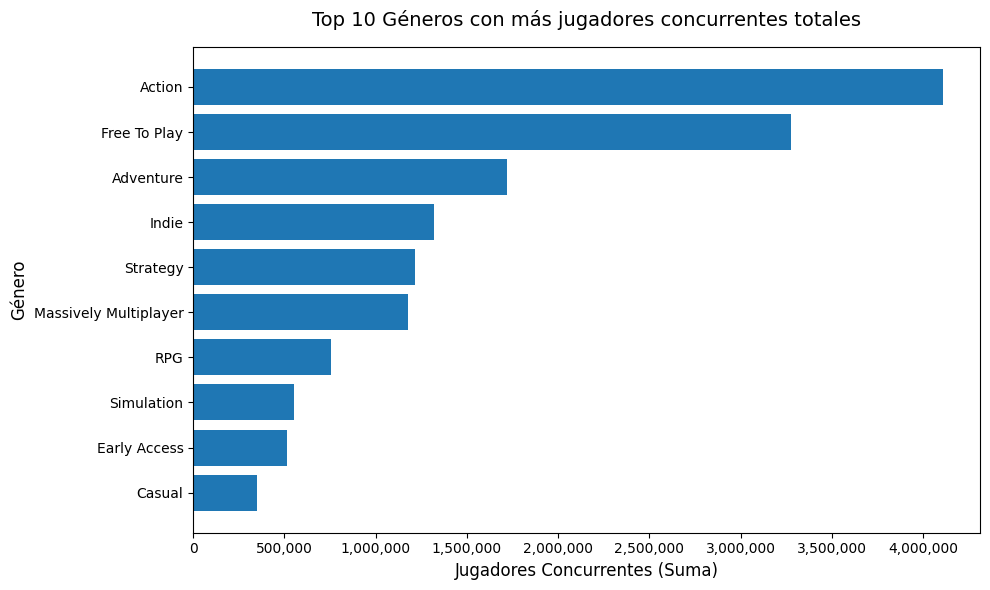

In [3]:
import matplotlib.pyplot as plt

# 1. Limpieza de datos: Separar géneros y expandirlos (explode)
# Convertimos el string "Action, RPG" en una lista ['Action', 'RPG'] y luego creamos una fila por cada uno
df_generos = df_super.assign(genero_indv=df_super['generos'].str.split(', ')).explode('genero_indv')

# 2. Agrupar por género y sumar jugadores
top_generos = df_generos.groupby('genero_indv')['jugadores_actuales'].sum().sort_values(ascending=True).tail(10)

# 3. Graficar con Matplotlib
fig2, ax = plt.subplots(figsize=(10, 6))
ax.barh(top_generos.index, top_generos.values, color='#1f77b4')

ax.set_title('Top 10 Géneros con más jugadores concurrentes totales', fontsize=14, pad=15)
ax.set_xlabel('Jugadores Concurrentes (Suma)', fontsize=12)
ax.set_ylabel('Género', fontsize=12)

# Formatear el eje X para que no salga en notación científica
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))
plt.tight_layout()
plt.show()

In [4]:
# Agrupamos sumando los jugadores por tipo de modelo de negocio
df_gratis = df_super.groupby('es_gratis')['jugadores_actuales'].sum().reset_index()

# Reemplazamos los booleanos por etiquetas legibles
df_gratis['es_gratis'] = df_gratis['es_gratis'].map({True: 'Free-to-Play', False: 'De Pago (Premium)'})

fig3 = px.pie(
    df_gratis, 
    names='es_gratis', 
    values='jugadores_actuales', 
    title='Proporción de jugadores en juegos Gratuitos vs De Pago',
    hole=0.4, # Lo convierte en un gráfico de Donut
    color='es_gratis',
    color_discrete_map={'Free-to-Play': '#00CC96', 'De Pago (Premium)': '#EF553B'}
)
fig3.show()

In [5]:
# Filtramos los juegos que tienen precio mayor a 0 y que tienen nota de Metacritic válida
df_precio = df_super[(df_super['precio_eur'] > 0) & (df_super['metacritic_nota'].notna())]

fig4 = px.scatter(
    df_precio, 
    x='precio_eur', 
    y='jugadores_actuales', 
    size='metacritic_nota', 
    hover_name='nombre',
    title='Relación entre Precio, Jugadores Concurrentes y Nota de Crítica (Metacritic)',
    labels={'precio_eur': 'Precio final (Euros)', 'jugadores_actuales': 'Jugadores Concurrentes'},
    size_max=20,
    template='plotly_white'
)
fig4.show()

In [6]:
# Sumamos cuántos juegos soportan cada plataforma
conteo_plataformas = {
    'Windows': df_super['windows'].sum(),
    'MacOS': df_super['mac'].sum(),
    'Linux': df_super['linux'].sum()
}

df_plataformas = pd.DataFrame(list(conteo_plataformas.items()), columns=['Plataforma', 'Cantidad de Juegos'])

fig5 = px.bar(
    df_plataformas, 
    x='Plataforma', 
    y='Cantidad de Juegos',
    title='Disponibilidad por Sistema Operativo (Top 50 Juegos Actuales)',
    text='Cantidad de Juegos',
    color='Plataforma',
    color_discrete_map={'Windows': '#00A4EF', 'MacOS': '#999999', 'Linux': '#FFB900'}
)
# Ubicamos el texto encima de las barras
fig5.update_traces(textposition='outside') 
fig5.show()

In [7]:
# Eliminamos los valores nulos para el histograma
df_notas = df_super[df_super['metacritic_nota'].notna()]

fig6 = px.histogram(
    df_notas, 
    x='metacritic_nota', 
    nbins=15, 
    title='Distribución de puntuaciones Metacritic en el Top de Juegos',
    labels={'metacritic_nota': 'Nota Metacritic (0-100)'},
    marginal='box', # Añade un boxplot en la parte superior para ver los cuartiles
    color_discrete_sequence=['#AB63FA']
)
fig6.show()